In [6]:
import os

path = "../data/processed/segmented_news.parquet"

print(os.path.exists(path))
print(os.path.getsize(path) / 1024 / 1024, "MB")

True
29.297094345092773 MB


In [7]:
import time
import pandas as pd

path = "../data/processed/segmented_news.parquet"

start = time.time()

df_seg = pd.read_parquet(path)

print("Loaded!")
print("Time:", round(time.time() - start, 2), "seconds")
print("Shape:", df_seg.shape)

Loaded!
Time: 0.11 seconds
Shape: (5764, 9)


In [8]:
#json turn into python list
import json

df_seg["tokens"] = df_seg["segmented_tokens"].apply(json.loads)

print(type(df_seg.loc[0, "tokens"]))
print(df_seg.loc[0, "tokens"][:30])

<class 'list'>
['走', '斑馬線', '還是', '被', '撞', '！', '新北', '高中生', '怒', '轟', '「', '你', '他', '眼', '瞎', '啊', '」', '影片', '瘋傳', '駕駛', '當下', '行為', '也', '曝光', '開車', '不', '看', '前方', '，', '駕駛']


In [9]:
#create the punctuation list
import string

punctuation = set(string.punctuation)

# 中文與全形標點
chinese_punctuation = set(
    "，。！？；：、（）「」『』【】〔〕"
    "〈〉《》“”‘’—–…·"
    "～﹏！＠＃＄％＆＊（）－＋＝"
    "［］｛｝｜／＼"
)

punctuation = punctuation | chinese_punctuation

print("Number of punctuation marks:", len(punctuation))


Number of punctuation marks: 79


In [10]:
#data cleaning
def clean_tokens(tokens):
    cleaned = []

    for token in tokens:
        token = token.strip()

        # 空字串
        if not token:
            continue

        # 標點符號
        if token in punctuation:
            continue

        cleaned.append(token)

    return cleaned


df_seg["clean_tokens"] = df_seg["tokens"].apply(clean_tokens)

print(df_seg[["tokens", "clean_tokens"]].head())

                                              tokens  \
0  [走, 斑馬線, 還是, 被, 撞, ！, 新北, 高中生, 怒, 轟, 「, 你, 他, ...   
1  [不, 接受, 「, 金門, 撞船, 案, 」, 專案, 報告, 名稱, 民進黨團, 明, ...   
2  [開刀, 住院, 3, 天, 申請, 實, 支, 實, 付, ！, 他, 見, 「, 3, ...   
3  [想要, 成功, ，, 要, 怎麼, 運用, 時間, ？, 專家, ：, 對, 這, 4, ...   
4  [台北, 某, 高中生, 打, 老師, ！, 疑, 不滿, 被, 訓, 「, 影響, 上課,...   

                                        clean_tokens  
0  [走, 斑馬線, 還是, 被, 撞, 新北, 高中生, 怒, 轟, 你, 他, 眼, 瞎, ...  
1  [不, 接受, 金門, 撞船, 案, 專案, 報告, 名稱, 民進黨團, 明, 甲, 動, ...  
2  [開刀, 住院, 3, 天, 申請, 實, 支, 實, 付, 他, 見, 3, 項目, 沒,...  
3  [想要, 成功, 要, 怎麼, 運用, 時間, 專家, 對, 這, 4, 個, 時間, 的,...  
4  [台北, 某, 高中生, 打, 老師, 疑, 不滿, 被, 訓, 影響, 上課, 突, 暴走...  


In [11]:
from collections import Counter

word_counts = Counter(
    token
    for tokens in df_seg["clean_tokens"]
    for token in tokens
)

print(word_counts.most_common(50))

[('的', 107718), ('是', 30351), ('在', 28788), ('一', 20618), ('有', 20616), ('也', 18579), ('不', 15818), ('這', 13053), ('了', 12722), ('會', 11528), ('就', 11352), ('個', 11213), ('與', 10902), ('人', 10763), ('都', 10569), ('和', 9475), ('他', 9363), ('台灣', 8667), ('但', 8445), ('對', 8420), ('要', 8301), ('後', 8176), ('上', 8070), ('將', 7604), ('中', 7563), ('年', 7437), ('我', 6890), ('為', 6778), ('表示', 6656), ('中國', 6340), ('而', 6311), ('讓', 6308), ('並', 6307), ('被', 6283), ('能', 5961), ('大', 5954), ('最', 5771), ('還', 5714), ('說', 5645), ('等', 5254), ('更', 5193), ('以', 5181), ('可以', 5054), ('次', 5051), ('及', 5028), ('很', 4896), ('時', 4867), ('來', 4831), ('元', 4744), ('到', 4665)]


In [12]:
#stopword list
stopwords = {
    "的", "是", "在", "有", "也", "不", "這", "了",
    "會", "就", "個", "與", "都", "和", "他",
    "但", "對", "要", "後", "將", "我", "為",
    "而", "讓", "並", "被", "能", "最", "還",
    "說", "等", "更", "以", "可以", "及", "很",
    "時", "來", "到", "一", "中",
    
    # 新聞常見但 topic information 較低
    "表示"
}

additional_stopwords = {
    "上", "次", "自己", "沒有", "之", "此", "於",
    "她", "或", "前", "多", "你", "名", "每",
    "則", "才", "好", "者", "可能", "因為",
    "從", "再", "已", "可", "兩", "我們",
    "至", "各", "因此", "又", "該"
}

stopwords.update(additional_stopwords)

print("Total stopwords:", len(stopwords))

additional_stopwords_2 = {
    "人", "年", "大", "元",
    "指出", "種", "新", "問題", "卻",
    "下", "天", "高", "用", "他們",
    "全", "認為", "內", "過", "只",
    "時間", "做", "如果", "就是",
    "看", "跟", "去", "著", "把",
    "沒", "其", "想", "不過"
}

stopwords.update(additional_stopwords_2)

print("Total stopwords:", len(stopwords))

Total stopwords: 73
Total stopwords: 105


In [13]:
#remove stopword and number
def remove_stopwords_and_numbers(tokens):
    return [
        token
        for token in tokens
        if token not in stopwords
        and not token.isdigit()
    ]

df_seg["clean_tokens"] = df_seg["clean_tokens"].apply(
    remove_stopwords_and_numbers
)

In [14]:
word_counts_clean = Counter(
    token
    for tokens in df_seg["clean_tokens"]
    for token in tokens
)

print(word_counts_clean.most_common(50))

[('台灣', 8667), ('中國', 6340), ('民進黨', 4017), ('美國', 3934), ('國民黨', 3557), ('總統', 3335), ('網友', 3220), ('民眾黨', 3215), ('政府', 2965), ('立委', 2964), ('公司', 2871), ('選舉', 2401), ('國家', 2381), ('吃', 2317), ('民眾', 2293), ('未', 2282), ('柯文哲', 2246), ('進行', 2228), ('許多', 2216), ('家', 2188), ('日', 2178), ('已經', 2170), ('賴清德', 2163), ('且', 2144), ('日本', 2139), ('支持', 2137), ('向', 2125), ('因', 2109), ('經濟', 2090), ('得', 2075), ('由', 2069), ('仍', 2067), ('地', 2046), ('事', 2018), ('國會', 2011), ('若', 2007), ('所', 2004), ('工作', 1977), ('月', 1969), ('歲', 1968), ('開始', 1924), ('曾', 1919), ('對於', 1918), ('未來', 1916), ('本', 1909), ('以及', 1890), ('政治', 1885), ('三', 1879), ('其他', 1853), ('第一', 1834)]


In [15]:
import re

def contains_number(token):
    return bool(re.search(r"\d", token))

def is_english_only(token):
    return bool(re.fullmatch(r"[A-Za-z]+", token))

In [16]:
#more strict, remove 2024年、10月、1000萬...
import re

def is_english_only(token):
    return bool(re.fullmatch(r"[A-Za-z]+", token))

df_seg["clean_tokens"] = df_seg["tokens"].apply(
    lambda tokens: [
        token
        for token in tokens
        if token not in punctuation
        and token not in stopwords
        and not contains_number(token)
        and not is_english_only(token)
    ]
)

In [17]:
#create Document-Term Matrix
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Create Document-Term Matrix
documents = df_seg["clean_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

print("TF-IDF shape:", tfidf_matrix.shape)

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print(feature_names[:100])

TF-IDF shape: (5764, 10000)
Vocabulary size: 10000
['com' 'cp值' 'https' 'mg' 'of' 'tw' 'www' '一一' '一下' '一下子' '一中' '一些' '一併'
 '一來' '一共' '一再' '一切' '一半' '一口氣' '一同' '一向' '一國兩制' '一如' '一定' '一家人' '一審' '一帶'
 '一度' '一律' '一成' '一手' '一方' '一方面' '一旦' '一早' '一時' '一月' '一樓' '一樣' '一步步' '一段'
 '一氧化碳' '一生' '一百' '一直' '一致' '一致性' '一舉' '一般' '一般人' '一般來說' '一萬' '一貫' '一起'
 '一路' '一輩子' '一連串' '一邊' '一陣子' '一面倒' '一體' '一點' '一點點' '丁學忠' '丈夫' '三分之一'
 '三分之二' '三十' '三千' '三峽' '三星' '三月' '三立' '三腳督' '三重' '三重區' '三高' '上下' '上任' '上來'
 '上前' '上千' '上升' '上午' '上台' '上司' '上場' '上學' '上將' '上山' '上市' '上市櫃' '上帝' '上廁所'
 '上揚' '上方' '上映' '上架' '上校' '上桌']


In [18]:
#Topic modeling
#LDA (Latent Dirichlet Allocation)
#create CounterVectorizer

from sklearn.feature_extraction.text import CountVectorizer

documents = df_seg["clean_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

count_vectorizer = CountVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.95
)

count_matrix = count_vectorizer.fit_transform(documents)

print("Count matrix shape:", count_matrix.shape)

Count matrix shape: (5764, 10000)


In [19]:
#k=10 
#baseline
from sklearn.decomposition import LatentDirichletAllocation

lda_10 = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    learning_method="batch",
    max_iter=20,
    n_jobs=-1
)

lda_10.fit(count_matrix)

print("LDA training finished!")

LDA training finished!


In [20]:
#baseline topic keyword
feature_names = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_10.components_):
    top_indices = topic.argsort()[-15:][::-1]
    top_words = [
        feature_names[i]
        for i in top_indices
    ]

    print(f"\nTopic {topic_idx + 1}:")
    print(" | ".join(top_words))


Topic 1:
網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理 | 發文 | 完整 | 真的 | 不少 | 臉書

Topic 2:
健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究 | 影響 | 天氣 | 幫助 | 血壓 | 水果

Topic 3:
民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國會 | 立法院 | 台灣 | 支持 | 韓國瑜 | 黨團 | 大選

Topic 4:
發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行 | 目前 | 學生 | 法院 | 導致 | 要求

Topic 5:
中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治 | 政策 | 大陸 | 國際 | 中共 | 德國

Topic 6:
日本 | 台灣 | 大學 | 美國 | 歷史 | 旅遊 | 國家 | 香港 | 國際 | 旅客 | 世界 | 川普 | 泰國 | 航空 | 日圓

Topic 7:
網友 | 什麼 | 工作 | 許多 | 台灣 | 這樣 | 大家 | 知道 | 生活 | 真的 | 孩子 | 開始 | 還是 | 不少 | 覺得

Topic 8:
政府 | 台灣 | 相關 | 安全 | 陳建仁 | 社會 | 要求 | 民眾 | 規定 | 業者 | 政策 | 進行 | 台電 | 機關 | 行政院

Topic 9:
工作 | 申請 | 獎金 | 民眾 | 春節 | 金額 | 今年 | 刮刮樂 | 紅包 | 補助 | 責任 | 銀行 | 財富 | 年終 | 期間

Topic 10:
公司 | 市場 | 投資 | 美元 | 全球 | 企業 | 台積電 | 產業 | 去年 | 今年 | 科技 | 技術 | 成長 | 半導體 | 員工


In [21]:
from sklearn.decomposition import LatentDirichletAllocation

lda_5 = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method="batch",
    max_iter=20,
    n_jobs=-1
)

lda_5.fit(count_matrix)

print("LDA K=5 training finished!")

LDA K=5 training finished!


In [22]:
#k = 5
feature_names = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_5.components_):
    top_indices = topic.argsort()[-15:][::-1]
    top_words = [
        feature_names[i]
        for i in top_indices
    ]

    print(f"\nTopic {topic_idx + 1}:")
    print(" | ".join(top_words))


Topic 1:
網友 | 許多 | 分享 | 台灣 | 不少 | 討論 | 編輯 | 真的 | 大家 | 使用 | 責任 | 發文 | 好吃 | 覺得 | 推薦

Topic 2:
健康 | 食物 | 醫師 | 建議 | 責任 | 容易 | 民眾 | 編輯 | 身體 | 影響 | 飲食 | 地區 | 幫助 | 注意 | 研究

Topic 3:
民進黨 | 國民黨 | 民眾黨 | 台灣 | 總統 | 立委 | 選舉 | 柯文哲 | 賴清德 | 國會 | 立法院 | 支持 | 大選 | 政治 | 韓國瑜

Topic 4:
發生 | 發現 | 事件 | 影片 | 孩子 | 工作 | 學生 | 台灣 | 警方 | 公司 | 人員 | 已經 | 調查 | 要求 | 對方

Topic 5:
中國 | 美國 | 台灣 | 公司 | 經濟 | 國家 | 政府 | 全球 | 市場 | 日本 | 投資 | 國際 | 去年 | 美元 | 今年


In [23]:
import gensim

print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [24]:
from gensim.models import CoherenceModel
# 取得 vocabulary
feature_names = count_vectorizer.get_feature_names_out()

# K=5 topics
topics_5 = []

for topic in lda_5.components_:
    top_indices = topic.argsort()[-15:][::-1]
    topics_5.append(
        [feature_names[i] for i in top_indices]
    )

# K=10 topics
topics_10 = []

for topic in lda_10.components_:
    top_indices = topic.argsort()[-15:][::-1]
    topics_10.append(
        [feature_names[i] for i in top_indices]
    )

In [25]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

texts = df_seg["clean_tokens"].tolist()

dictionary = Dictionary(texts)

coherence_5 = CoherenceModel(
    topics=topics_5,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

score_5 = coherence_5.get_coherence()

print("K=5 Coherence:", score_5)

K=5 Coherence: 0.6085067439600486


In [26]:
coherence_10 = CoherenceModel(
    topics=topics_10,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

score_10 = coherence_10.get_coherence()

print("K=10 Coherence:", score_10)

K=10 Coherence: 0.6039277359270665


In [27]:
coherence_5_per_topic = CoherenceModel(
    topics=topics_5,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

scores_5 = coherence_5_per_topic.get_coherence_per_topic()

for i, score in enumerate(scores_5):
    print(f"Topic {i+1}: {score:.4f}")

Topic 1: 0.5829
Topic 2: 0.5219
Topic 3: 0.8319
Topic 4: 0.4703
Topic 5: 0.6355


In [28]:
coherence_10_per_topic = CoherenceModel(
    topics=topics_10,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

scores_10 = coherence_10_per_topic.get_coherence_per_topic()

for i, score in enumerate(scores_10):
    print(f"Topic {i+1}: {score:.4f}")

Topic 1: 0.6283
Topic 2: 0.6853
Topic 3: 0.8415
Topic 4: 0.5047
Topic 5: 0.6915
Topic 6: 0.4544
Topic 7: 0.4875
Topic 8: 0.5200
Topic 9: 0.4736
Topic 10: 0.7524


In [29]:
#k=15
from sklearn.decomposition import LatentDirichletAllocation

lda_15 = LatentDirichletAllocation(
    n_components=15,
    random_state=42,
    learning_method="batch",
    max_iter=20,
    n_jobs=-1
)

lda_15.fit(count_matrix)

print("LDA K=15 training finished!")

LDA K=15 training finished!


In [30]:
feature_names = count_vectorizer.get_feature_names_out()

topics_15 = []

for topic in lda_15.components_:
    top_indices = topic.argsort()[-15:][::-1]
    
    top_words = [
        feature_names[i]
        for i in top_indices
    ]
    
    topics_15.append(top_words)

for i, words in enumerate(topics_15):
    print(f"\nTopic {i+1}:")
    print(" | ".join(words))


Topic 1:
大學 | 使用 | 透過 | 文化 | 生活 | 功能 | 研究 | 這些 | 以及 | 不同 | 方式 | 進行 | 活動 | 社群 | 工作

Topic 2:
台糖 | 農曆 | 瘦肉精 | 民眾 | 過年 | 春節 | 醫院 | 食安 | 檢驗 | 食品 | 祭拜 | 檢出 | 禁忌 | 準備 | 醫師

Topic 3:
國民黨 | 民進黨 | 民眾黨 | 立委 | 柯文哲 | 國會 | 選舉 | 立法院 | 總統 | 韓國瑜 | 黨團 | 賴清德 | 支持 | 黃國昌 | 候選人

Topic 4:
發生 | 警方 | 發現 | 孩子 | 男子 | 調查 | 事件 | 學生 | 影片 | 當時 | 目前 | 現場 | 人員 | 法院 | 已經

Topic 5:
中國 | 美國 | 公司 | 川普 | 烏克蘭 | 報導 | 俄羅斯 | 德國 | 國家 | 政府 | 華爾街日報 | 全球 | 美元 | 去年 | 英國

Topic 6:
日本 | 優惠 | 咖啡 | 美國 | 以色列 | 泰國 | 活動 | 國家 | 日圓 | 電影 | 地區 | 東京 | 推出 | 世界 | 戰爭

Topic 7:
網友 | 真的 | 許多 | 大家 | 不少 | 什麼 | 討論 | 分享 | 台灣 | 發文 | 覺得 | 這樣 | 知道 | 還是 | 看到

Topic 8:
台電 | 政府 | 台灣 | 交通 | 土地 | 民眾 | 安全 | 台中 | 台北市 | 房價 | 電價 | 賀瓏 | 王志安 | 陳俊翰 | 能源

Topic 9:
工作 | 獎金 | 申請 | 銀行 | 金額 | 刮刮樂 | 補助 | 年終 | 勞工 | 責任 | 今年 | 生活 | 紅包 | 民眾 | 發放

Topic 10:
公司 | 台積電 | 產業 | 台灣 | 市場 | 科技 | 美元 | 半導體 | 企業 | 全球 | 晶片 | 技術 | 今年 | 去年 | 發展

Topic 11:
中國 | 金門 | 台灣 | 兩岸 | 大陸 | 事件 | 海域 | 旅客 | 海巡署 | 旅遊 | 國防部 | 執法 | 施明德 | 海巡 | 漁船

Topic 12:
經濟 | 投資 | 中國 | 市場 | 美國 | 影響 | 股市 | 成長 | 指數 | 全球 |

In [31]:
#calculate overall coherence
from gensim.models import CoherenceModel

coherence_15 = CoherenceModel(
    topics=topics_15,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

score_15 = coherence_15.get_coherence()

print("K=15 Coherence:", score_15)

K=15 Coherence: 0.56207841068676


In [32]:
scores_15 = coherence_15.get_coherence_per_topic()

for i, score in enumerate(scores_15):
    print(f"Topic {i+1}: {score:.4f}")

Topic 1: 0.4051
Topic 2: 0.3386
Topic 3: 0.8806
Topic 4: 0.5785
Topic 5: 0.6880
Topic 6: 0.3377
Topic 7: 0.6049
Topic 8: 0.2537
Topic 9: 0.4784
Topic 10: 0.7315
Topic 11: 0.6181
Topic 12: 0.6121
Topic 13: 0.7009
Topic 14: 0.5738
Topic 15: 0.6293


We choose k = 10, for the overall coherence and semantic interpretability

In [33]:
# Get topic probabilities for every article
topic_distribution = lda_10.transform(count_matrix)

print("Topic distribution shape:", topic_distribution.shape)

Topic distribution shape: (5764, 10)


In [34]:
#to find every dominant topic of the text
import numpy as np

dominant_topic = np.argmax(topic_distribution, axis=1)
dominant_probability = np.max(topic_distribution, axis=1)

print("Dominant topic example:", dominant_topic[:10])
print("Dominant probability example:", dominant_probability[:10])

Dominant topic example: [3 2 8 6 3 1 4 6 0 9]
Dominant probability example: [0.77099996 0.70386829 0.42652842 0.69937085 0.79248335 0.64204025
 0.35837867 0.43906017 0.55103754 0.47936368]


In [35]:
#create dataframe
df_seg["dominant_topic"] = dominant_topic + 1
df_seg["dominant_probability"] = dominant_probability

print(df_seg.shape)
print(
    df_seg[
        [
            "title",
            "tag",
            "dominant_topic",
            "dominant_probability"
        ]
    ].head(10)
)

(5764, 13)
                                    title  tag  dominant_topic  \
0  走斑馬線還是被撞！新北高中生怒轟「你他X眼瞎啊」影片瘋傳　駕駛當下行為也曝光  風生活               4   
1         不接受「金門撞船案」專案報告名稱　民進黨團明甲動：力挺國家執法   政治               3   
2        開刀住院3天申請實支實付！他見「3項目沒理賠」氣炸，網一面倒不挺  風生活               9   
3         想要成功，要怎麼運用時間？專家：對這4個時間的投資絕對不能吝嗇  風生活               7   
4  台北某高中生打老師！疑不滿被訓「影響上課」突暴走　比中指、鎖喉揮拳畫面全被拍  風生活               4   
5          別再猛吞白飯、大量喝水！魚刺卡喉嚨怎麼辦？醫師揭正確處理方法  風生活               2   
6                美國在馬紹爾群島核試爆70周年　受害者求償路漫長   國際               5   
7    洋芋片為何要做成彎的「馬鞍形」、讓人無法一口吃完？原來背後設計理念超心機  風生活               7   
8      別插在延長線！台電曝光「4大快煮壺NG行為」，做錯小心觸電、引發火災  風生活               1   
9        熊本廠成台積電金雞母？蔡正元揭三大利多：反觀美國廠只能咬牙洗下去   政治              10   

   dominant_probability  
0              0.771000  
1              0.703868  
2              0.426528  
3              0.699371  
4              0.792483  
5              0.642040  
6              0.358379  
7              0.439060  
8              0.551038  
9 

In [36]:
topic_counts = (
    df_seg["dominant_topic"]
    .value_counts()
    .sort_index()
)

print(topic_counts)

topic_distribution_percent = (
    topic_counts / len(df_seg) * 100
).round(2)

print(topic_distribution_percent)

dominant_topic
1      453
2      467
3     1078
4      666
5      681
6      156
7      960
8      349
9      333
10     621
Name: count, dtype: int64
dominant_topic
1      7.86
2      8.10
3     18.70
4     11.55
5     11.81
6      2.71
7     16.66
8      6.05
9      5.78
10    10.77
Name: count, dtype: float64


In [37]:
#compare topic to the original one
topic_tag_table = pd.crosstab(
    df_seg["dominant_topic"],
    df_seg["tag"]
)

print(topic_tag_table)

topic_tag_percentage = pd.crosstab(
    df_seg["dominant_topic"],
    df_seg["tag"],
    normalize="index"
) * 100

print(topic_tag_percentage.round(2))

tag             中央社  中港澳  公共政策  公民運動  品味生活  國內   國際   政治  科技   評論  財經  風生活
dominant_topic                                                            
1                 0    0     0     0     9   2    0    1   0    0   0  441
2                 0    0     0     0     1   4    7   16   0    3   1  435
3                 0    0     0     0     0   0   16  828   0  178   1   55
4                 0    0     1     1     0  11   24   64   0   28   1  536
5                 0    1     0     0     0   3  330   89   0  183  15   60
6                 1    1     0     0     3   4   29   18   0   22   4   74
7                 0    0     0     2    17   8   33   34   0  123  14  729
8                 0    0     0     0     2  10    3  176   0   91   0   67
9                 0    0     1     0     3  16    3    9   0   10   4  287
10                0    6     0     0    17  68   46   22   1   40  71  350
tag              中央社   中港澳  公共政策  公民運動  品味生活     國內     國際     政治    科技  \
dominant_topic           

In [38]:
#dataframe
import pandas as pd

topic_tag_pct = pd.crosstab(
    df_seg["dominant_topic"],
    df_seg["tag"],
    normalize="index"
) * 100

topic_tag_pct = topic_tag_pct.round(2)

print(topic_tag_pct)

tag              中央社   中港澳  公共政策  公民運動  品味生活     國內     國際     政治    科技  \
dominant_topic                                                            
1               0.00  0.00  0.00  0.00  1.99   0.44   0.00   0.22  0.00   
2               0.00  0.00  0.00  0.00  0.21   0.86   1.50   3.43  0.00   
3               0.00  0.00  0.00  0.00  0.00   0.00   1.48  76.81  0.00   
4               0.00  0.00  0.15  0.15  0.00   1.65   3.60   9.61  0.00   
5               0.00  0.15  0.00  0.00  0.00   0.44  48.46  13.07  0.00   
6               0.64  0.64  0.00  0.00  1.92   2.56  18.59  11.54  0.00   
7               0.00  0.00  0.00  0.21  1.77   0.83   3.44   3.54  0.00   
8               0.00  0.00  0.00  0.00  0.57   2.87   0.86  50.43  0.00   
9               0.00  0.00  0.30  0.00  0.90   4.80   0.90   2.70  0.00   
10              0.00  0.97  0.00  0.00  2.74  10.95   7.41   3.54  0.16   

tag                評論     財經    風生活  
dominant_topic                       
1                0.00  

In [39]:
import matplotlib.font_manager as fm

font_path = "/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc"

font_prop = fm.FontProperties(fname=font_path)

print(font_prop.get_name())

Noto Sans CJK JP


In [40]:
import os

font_path = os.path.expanduser(
    "~/.local/share/fonts/NotoSansCJK-Regular.ttc"
)

print(font_path)
print("Exists:", os.path.exists(font_path))

/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc
Exists: True


In [41]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(font_path)

font_prop = fm.FontProperties(fname=font_path)

print("Font:", font_prop.get_name())

Font: Noto Sans CJK JP


/home/yuli6752/miniconda3/envs/chinese_nlp/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/yuli6752/miniconda3/envs/chinese_nlp/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22830 (\N{CJK UNIFIED IDEOGRAPH-592E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/yuli6752/miniconda3/envs/chinese_nlp/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 31038 (\N{CJK UNIFIED IDEOGRAPH-793E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/yuli6752/miniconda3/envs/chinese_nlp/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28207 (\N{CJK UNIFIED IDEOGRAPH-6E2F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/yuli6752/miniconda3/envs/chinese_nlp/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28595 (\N{CJK UNIFIED IDEOGRAPH-6FB3}) missing from font(s) DejaVu S

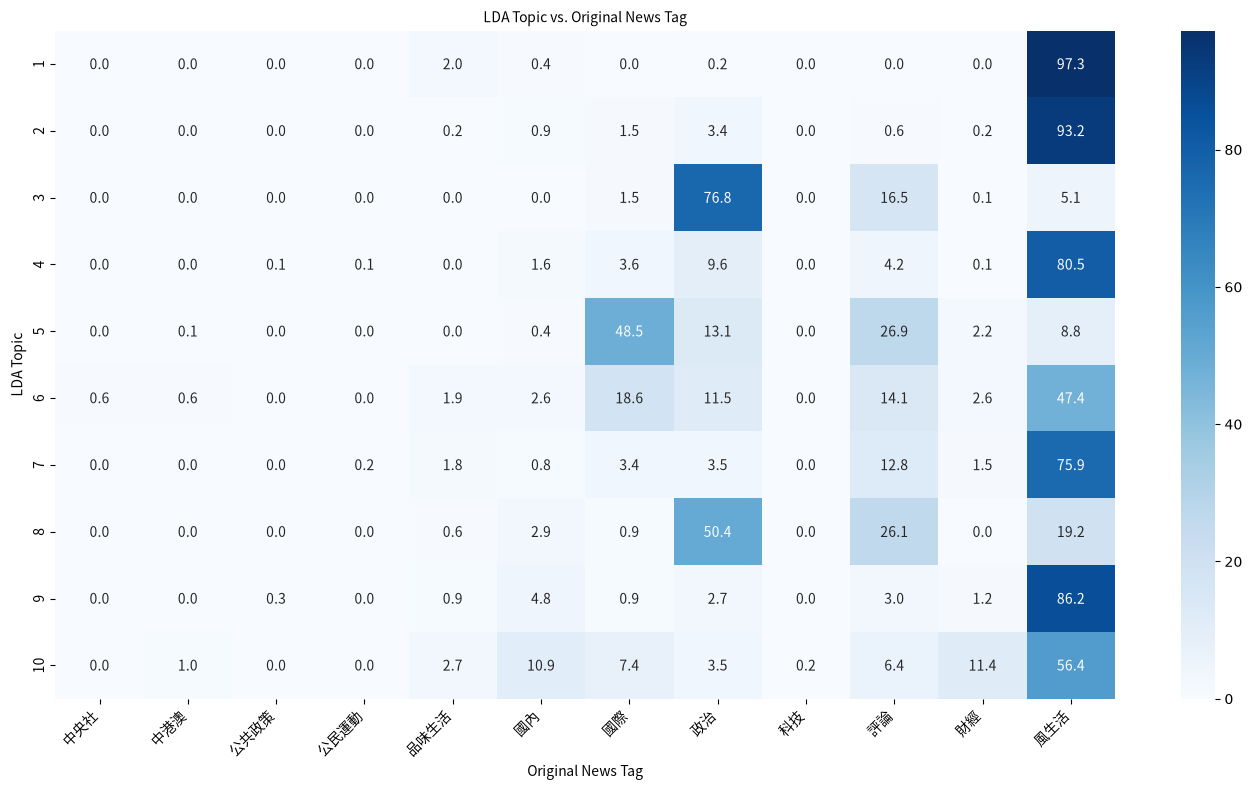

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))

ax = sns.heatmap(
    topic_tag_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

# X-axis
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
    label.set_rotation(45)
    label.set_ha("right")

# Y-axis
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)

# Numbers inside heatmap
for text in ax.texts:
    text.set_fontproperties(font_prop)

ax.set_xlabel(
    "Original News Tag",
    fontproperties=font_prop
)

ax.set_ylabel(
    "LDA Topic",
    fontproperties=font_prop
)

ax.set_title(
    "LDA Topic vs. Original News Tag",
    fontproperties=font_prop
)

plt.tight_layout()
plt.show()

In [43]:
#topic purity
topic_purity = topic_tag_pct.max(axis=1)

topic_main_tag = topic_tag_pct.idxmax(axis=1)

topic_purity_table = pd.DataFrame({
    "Main Tag": topic_main_tag,
    "Purity (%)": topic_purity
})

print(topic_purity_table.round(2))

               Main Tag  Purity (%)
dominant_topic                     
1                   風生活       97.35
2                   風生活       93.15
3                    政治       76.81
4                   風生活       80.48
5                    國際       48.46
6                   風生活       47.44
7                   風生活       75.94
8                    政治       50.43
9                   風生活       86.19
10                  風生活       56.36


In [44]:
#sort
topic_purity_table = topic_purity_table.sort_values(
    "Purity (%)",
    ascending=False
)

print(topic_purity_table.round(2))

               Main Tag  Purity (%)
dominant_topic                     
1                   風生活       97.35
2                   風生活       93.15
9                   風生活       86.19
4                   風生活       80.48
3                    政治       76.81
7                   風生活       75.94
10                  風生活       56.36
8                    政治       50.43
5                    國際       48.46
6                   風生活       47.44


In [45]:
#find the most inconsistent topics
print(
    topic_purity_table.sort_values(
        "Purity (%)"
    ).head(5).round(2)
)

               Main Tag  Purity (%)
dominant_topic                     
6                   風生活       47.44
5                    國際       48.46
8                    政治       50.43
10                  風生活       56.36
7                   風生活       75.94


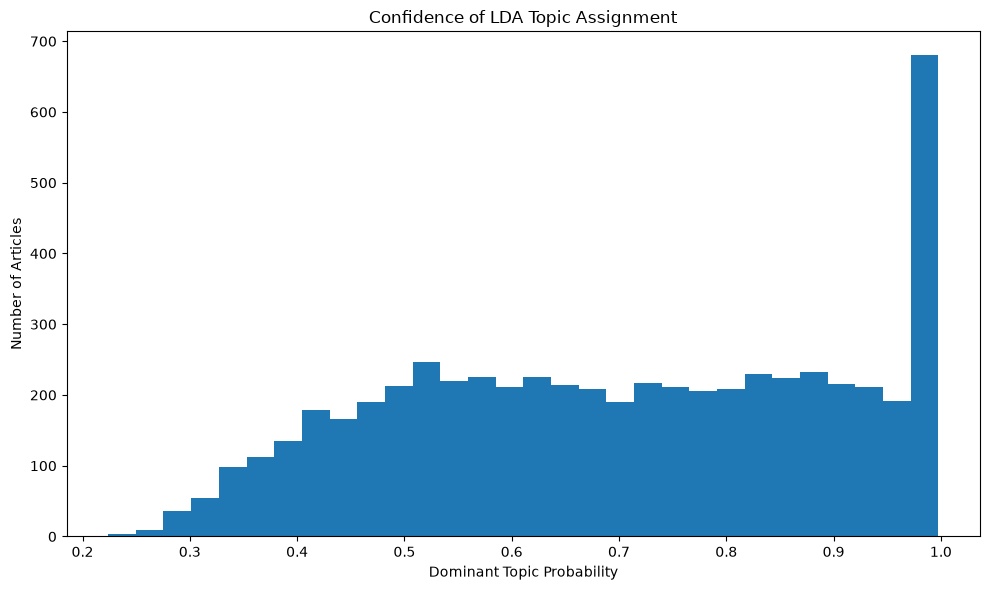

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df_seg["dominant_probability"],
    bins=30
)

plt.xlabel("Dominant Topic Probability")
plt.ylabel("Number of Articles")
plt.title("Confidence of LDA Topic Assignment")

plt.tight_layout()
plt.show()

In [47]:
print(
    "Mean confidence:",
    round(df_seg["dominant_probability"].mean(), 4)
)

print(
    "Median confidence:",
    round(df_seg["dominant_probability"].median(), 4)
)

Mean confidence: 0.7009
Median confidence: 0.7075


Topic co-occurrence network

In [48]:
#to get doc-topic probability matrix
doc_topic_matrix = lda_10.transform(count_matrix)
print(doc_topic_matrix.shape)  # (n_docs, 10)

(5764, 10)


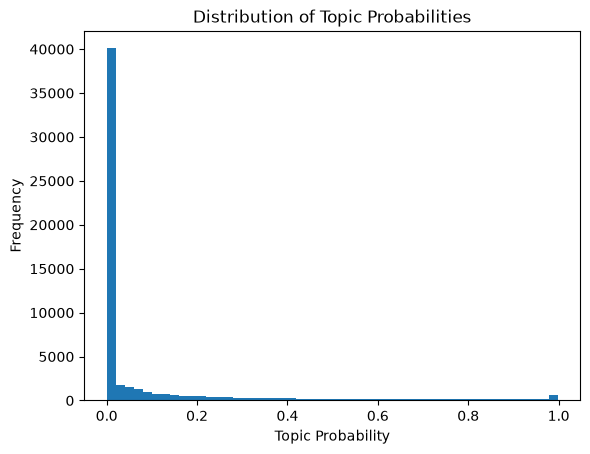

threshold=0.1: 平均每篇文件涉及 2.09 個topics
threshold=0.15: 平均每篇文件涉及 1.77 個topics
threshold=0.2: 平均每篇文件涉及 1.55 個topics
threshold=0.25: 平均每篇文件涉及 1.37 個topics
threshold=0.3: 平均每篇文件涉及 1.22 個topics


In [49]:
#to see the ditribution of the probability and then decide the threshold
import numpy as np
import matplotlib.pyplot as plt

all_probs = doc_topic_matrix.flatten()
plt.hist(all_probs, bins=50)
plt.xlabel('Topic Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Topic Probabilities')
plt.show()

for th in [0.1, 0.15, 0.2, 0.25, 0.3]:
    avg_topics = (doc_topic_matrix > th).sum(axis=1).mean()
    print(f"threshold={th}: 平均每篇文件涉及 {avg_topics:.2f} 個topics")

In [50]:
for th in [0.03, 0.05, 0.08, 0.1]:
    avg_topics = (doc_topic_matrix > th).sum(axis=1).mean()
    print(f"threshold={th}: 平均每篇文件涉及 {avg_topics:.2f} 個topics")

threshold=0.03: 平均每篇文件涉及 2.90 個topics
threshold=0.05: 平均每篇文件涉及 2.61 個topics
threshold=0.08: 平均每篇文件涉及 2.26 個topics
threshold=0.1: 平均每篇文件涉及 2.09 個topics


In [51]:
import subprocess
result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
print(result.stdout)

/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans CJK JP:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans CJK KR:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans CJK HK:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans CJK SC:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans CJK TC:style=Regular
/usr/share/fonts/google-droid-sans-fonts/DroidSansFallbackFull.ttf: Droid Sans,Droid Sans Fallback:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans Mono CJK SC:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans Mono CJK TC:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans Mono CJK KR:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc: Noto Sans Mono CJK HK:style=Regular
/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc

In [52]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 每篇文章的 dominant topic
topics = df_seg["dominant_topic"].dropna().tolist()

# 找出所有 topics
unique_topics = sorted(set(topics))

print("Topics:", unique_topics)

Topics: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [53]:
[x for x in globals().keys()
 if any(word in x.lower()
        for word in ["prob", "topic", "distribution", "matrix"])]

['tfidf_matrix',
 'count_matrix',
 'topic_idx',
 'topic',
 'topics_5',
 'topics_10',
 'coherence_5_per_topic',
 'coherence_10_per_topic',
 'topics_15',
 'topic_distribution',
 'dominant_topic',
 'dominant_probability',
 'topic_counts',
 'topic_distribution_percent',
 'topic_tag_table',
 'topic_tag_percentage',
 'topic_tag_pct',
 'topic_purity',
 'topic_main_tag',
 'topic_purity_table',
 'doc_topic_matrix',
 'all_probs',
 'avg_topics',
 'topics',
 'unique_topics']

In [54]:
print(type(doc_topic_matrix))
print(doc_topic_matrix.shape)
print(doc_topic_matrix[:3])

<class 'numpy.ndarray'>
(5764, 10)
[[5.49556178e-04 5.49512853e-04 5.49539753e-04 7.70999963e-01
  5.49514400e-04 5.49517910e-04 2.24603801e-01 5.49559015e-04
  5.49519907e-04 5.49516216e-04]
 [5.26408107e-04 5.26390780e-04 7.03868286e-01 1.29832397e-01
  5.26441170e-04 5.26383529e-04 5.26471658e-04 1.62614459e-01
  5.26360691e-04 5.26402412e-04]
 [2.18977083e-01 7.30097004e-04 7.30007865e-04 1.62358202e-01
  7.30044662e-04 7.30004744e-04 1.87755937e-01 7.30097473e-04
  4.26528421e-01 7.30105007e-04]]


In [55]:
import numpy as np
import pandas as pd

# 確認 shape
print(doc_topic_matrix.shape)

# 每篇文章中，probability >= threshold 的 topics
threshold = 0.10

topic_presence = doc_topic_matrix >= threshold

print(topic_presence.shape)

(5764, 10)
(5764, 10)


In [56]:
import numpy as np
import pandas as pd

threshold = 0.10

# True / False → 1 / 0
topic_presence = (
    np.asarray(doc_topic_matrix) >= threshold
).astype(int)

print("topic_presence shape:", topic_presence.shape)

# topic-topic co-occurrence
cooc_matrix = topic_presence.T @ topic_presence

# 明確轉成 int
cooc_matrix = np.asarray(cooc_matrix, dtype=int)

# 建立 DataFrame
cooc_df = pd.DataFrame(
    cooc_matrix,
    index=range(1, 11),
    columns=range(1, 11)
)

# 對角線設為 0
for topic in cooc_df.index:
    cooc_df.loc[topic, topic] = 0

print("\n=== Co-occurrence Matrix ===")
print(cooc_df)

topic_presence shape: (5764, 10)

=== Co-occurrence Matrix ===
     1    2    3    4    5    6    7    8    9    10
1     0  265    9   79   21   69  376   44   80   89
2   265    0   33  112   42   61  263  123   86   68
3     9   33    0  206  416  106  353  376   53   69
4    79  112  206    0  249  183  519  254  113  160
5    21   42  416  249    0  330  336  201  100  494
6    69   61  106  183  330    0  405  128   87  207
7   376  263  353  519  336  405    0  266  399  436
8    44  123  376  254  201  128  266    0  157  231
9    80   86   53  113  100   87  399  157    0  284
10   89   68   69  160  494  207  436  231  284    0


In [57]:
print("\nTotal co-occurrence:", cooc_df.values.sum())
print("Maximum:", cooc_df.values.max())


Total co-occurrence: 17876
Maximum: 519


In [58]:
G = nx.Graph()

for topic in cooc_df.index:
    G.add_node(topic)

for i in cooc_df.index:
    for j in cooc_df.columns:
        if i < j and cooc_df.loc[i, j] > 0:
            G.add_edge(
                i,
                j,
                weight=float(cooc_df.loc[i, j])
            )

print("\nNodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 10
Edges: 45


In [59]:
import numpy as np
import pandas as pd
import networkx as nx
from itertools import combinations
from math import log

threshold = 0.10

# 每篇文章哪些 topics 被認為「出現」
presence = (doc_topic_matrix >= threshold).astype(int)

print("Documents:", presence.shape[0])
print("Topics:", presence.shape[1])

Documents: 5764
Topics: 10


In [60]:
cooc_matrix = presence.T @ presence

# 轉成 DataFrame
cooc_df = pd.DataFrame(
    cooc_matrix,
    index=range(1, 11),
    columns=range(1, 11)
)

# 自己跟自己不算
for topic in cooc_df.index:
    cooc_df.loc[topic, topic] = 0

print("=== Raw Co-occurrence ===")
print(cooc_df)

=== Raw Co-occurrence ===
     1    2    3    4    5    6    7    8    9    10
1     0  265    9   79   21   69  376   44   80   89
2   265    0   33  112   42   61  263  123   86   68
3     9   33    0  206  416  106  353  376   53   69
4    79  112  206    0  249  183  519  254  113  160
5    21   42  416  249    0  330  336  201  100  494
6    69   61  106  183  330    0  405  128   87  207
7   376  263  353  519  336  405    0  266  399  436
8    44  123  376  254  201  128  266    0  157  231
9    80   86   53  113  100   87  399  157    0  284
10   89   68   69  160  494  207  436  231  284    0


In [61]:
#計算PMI
n_docs = presence.shape[0]

# 每個 topic 出現的文件數
topic_counts = presence.sum(axis=0)

# topic probability
topic_prob = topic_counts / n_docs

pmi_edges = []

for i, j in combinations(range(10), 2):

    # 共現文件數
    cooc_count = cooc_matrix[i, j]

    if cooc_count == 0:
        continue

    # P(i,j)
    p_ij = cooc_count / n_docs

    # P(i), P(j)
    p_i = topic_prob[i]
    p_j = topic_prob[j]

    # PMI
    pmi = np.log(p_ij / (p_i * p_j))

    pmi_edges.append({
        "topic_a": i + 1,
        "topic_b": j + 1,
        "PMI": pmi,
        "raw_count": int(cooc_count)
    })

pmi_df = pd.DataFrame(pmi_edges)

print("Number of topic pairs:", len(pmi_df))
print(pmi_df.sort_values("PMI", ascending=False).head(10))

Number of topic pairs: 45
    topic_a  topic_b       PMI  raw_count
0         1        2  0.786932        265
30        5        6  0.487276        330
34        5       10  0.427821        494
44        9       10  0.423334        284
21        3        8  0.331966        376
35        6        7  0.261669        405
40        7        9  0.223614        399
27        4        8  0.159507        254
5         1        7  0.143991        376
38        6       10  0.130208        207


In [62]:
print("\n=== Top 10 共現配對 (by PMI) ===")

top_pmi = pmi_df.sort_values(
    "PMI",
    ascending=False
).head(10)

for _, row in top_pmi.iterrows():
    print(
        f"Topic {int(row['topic_a'])} "
        f"<-> Topic {int(row['topic_b'])}: "
        f"PMI={row['PMI']:.3f}, "
        f"raw_count={int(row['raw_count'])}"
    )


=== Top 10 共現配對 (by PMI) ===
Topic 1 <-> Topic 2: PMI=0.787, raw_count=265
Topic 5 <-> Topic 6: PMI=0.487, raw_count=330
Topic 5 <-> Topic 10: PMI=0.428, raw_count=494
Topic 9 <-> Topic 10: PMI=0.423, raw_count=284
Topic 3 <-> Topic 8: PMI=0.332, raw_count=376
Topic 6 <-> Topic 7: PMI=0.262, raw_count=405
Topic 7 <-> Topic 9: PMI=0.224, raw_count=399
Topic 4 <-> Topic 8: PMI=0.160, raw_count=254
Topic 1 <-> Topic 7: PMI=0.144, raw_count=376
Topic 6 <-> Topic 10: PMI=0.130, raw_count=207


In [63]:
# ==========================================
# 使用你原本的 PMI threshold
# ==========================================

PMI_THRESHOLD = 0.05

G = nx.Graph()

# 加入 10 個 topics
for topic in range(1, 11):
    G.add_node(topic)

# 加入 PMI > 0.05 的 edges
for _, row in pmi_df.iterrows():

    if row["PMI"] > PMI_THRESHOLD:

        G.add_edge(
            int(row["topic_a"]),
            int(row["topic_b"]),
            weight=float(row["PMI"]),
            raw_count=int(row["raw_count"])
        )

print("PMI threshold:", PMI_THRESHOLD)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print("\n=== Edges ===")

for u, v, d in sorted(
    G.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
):
    print(
        f"Topic {u} <-> Topic {v}: "
        f"PMI={d['weight']:.3f}, "
        f"raw_count={d['raw_count']}"
    )

PMI threshold: 0.05
Nodes: 10
Edges: 13

=== Edges ===
Topic 1 <-> Topic 2: PMI=0.787, raw_count=265
Topic 5 <-> Topic 6: PMI=0.487, raw_count=330
Topic 5 <-> Topic 10: PMI=0.428, raw_count=494
Topic 9 <-> Topic 10: PMI=0.423, raw_count=284
Topic 3 <-> Topic 8: PMI=0.332, raw_count=376
Topic 6 <-> Topic 7: PMI=0.262, raw_count=405
Topic 7 <-> Topic 9: PMI=0.224, raw_count=399
Topic 4 <-> Topic 8: PMI=0.160, raw_count=254
Topic 1 <-> Topic 7: PMI=0.144, raw_count=376
Topic 6 <-> Topic 10: PMI=0.130, raw_count=207
Topic 8 <-> Topic 9: PMI=0.092, raw_count=157
Topic 4 <-> Topic 7: PMI=0.073, raw_count=519
Topic 3 <-> Topic 5: PMI=0.062, raw_count=416


In [64]:
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(
    G,
    weight="weight"
)

print("\n=== Communities ===")

for i, community in enumerate(communities):
    print(f"Community {i}: {sorted(community)}")


=== Communities ===
Community 0: [5, 6, 7, 9, 10]
Community 1: [3, 4, 8]
Community 2: [1, 2]


In [65]:
degree_centrality = nx.degree_centrality(G)

print("\n=== Degree Centrality ===")

for topic, value in sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"Topic {topic}: {value:.3f}")


=== Degree Centrality ===
Topic 7: 0.444
Topic 5: 0.333
Topic 6: 0.333
Topic 8: 0.333
Topic 9: 0.333
Topic 10: 0.333
Topic 1: 0.222
Topic 3: 0.222
Topic 4: 0.222
Topic 2: 0.111


In [66]:
topic_labels = {
    1: "風生活\nTopic 1",
    2: "風生活\nTopic 2",
    3: "政治\nTopic 3",
    4: "風生活\nTopic 4",
    5: "政治\nTopic 5",
    6: "風生活\nTopic 6",
    7: "風生活\nTopic 7",
    8: "政治\nTopic 8",
    9: "風生活\nTopic 9",
    10: "風生活\nTopic 10"
}

In [67]:
# ==========================================
# 取得 LDA 10 topics 的 Top 15 keywords
# ==========================================

feature_names = count_vectorizer.get_feature_names_out()

topic_keywords = {}

for topic_idx, topic in enumerate(lda_10.components_):

    top_indices = topic.argsort()[-15:][::-1]

    top_words = [
        feature_names[i]
        for i in top_indices
    ]

    topic_keywords[topic_idx + 1] = top_words

    print(f"\nTopic {topic_idx + 1}:")
    print(" | ".join(top_words))


Topic 1:
網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理 | 發文 | 完整 | 真的 | 不少 | 臉書

Topic 2:
健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究 | 影響 | 天氣 | 幫助 | 血壓 | 水果

Topic 3:
民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國會 | 立法院 | 台灣 | 支持 | 韓國瑜 | 黨團 | 大選

Topic 4:
發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行 | 目前 | 學生 | 法院 | 導致 | 要求

Topic 5:
中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治 | 政策 | 大陸 | 國際 | 中共 | 德國

Topic 6:
日本 | 台灣 | 大學 | 美國 | 歷史 | 旅遊 | 國家 | 香港 | 國際 | 旅客 | 世界 | 川普 | 泰國 | 航空 | 日圓

Topic 7:
網友 | 什麼 | 工作 | 許多 | 台灣 | 這樣 | 大家 | 知道 | 生活 | 真的 | 孩子 | 開始 | 還是 | 不少 | 覺得

Topic 8:
政府 | 台灣 | 相關 | 安全 | 陳建仁 | 社會 | 要求 | 民眾 | 規定 | 業者 | 政策 | 進行 | 台電 | 機關 | 行政院

Topic 9:
工作 | 申請 | 獎金 | 民眾 | 春節 | 金額 | 今年 | 刮刮樂 | 紅包 | 補助 | 責任 | 銀行 | 財富 | 年終 | 期間

Topic 10:
公司 | 市場 | 投資 | 美元 | 全球 | 企業 | 台積電 | 產業 | 去年 | 今年 | 科技 | 技術 | 成長 | 半導體 | 員工


In [68]:
topic_labels = {}

for topic, words in topic_keywords.items():

    # 取前 5 個 keyword
    label = "\n".join(words[:5])

    topic_labels[topic] = label

print(topic_labels)

{1: '網友\n分享\n好吃\n使用\n許多', 2: '健康\n食物\n醫師\n身體\n飲食', 3: '民進黨\n國民黨\n民眾黨\n立委\n總統', 4: '發生\n發現\n警方\n事件\n人員', 5: '中國\n台灣\n美國\n經濟\n國家', 6: '日本\n台灣\n大學\n美國\n歷史', 7: '網友\n什麼\n工作\n許多\n台灣', 8: '政府\n台灣\n相關\n安全\n陳建仁', 9: '工作\n申請\n獎金\n民眾\n春節', 10: '公司\n市場\n投資\n美元\n全球'}


findfont: Failed to find font weight bold, now using 400.


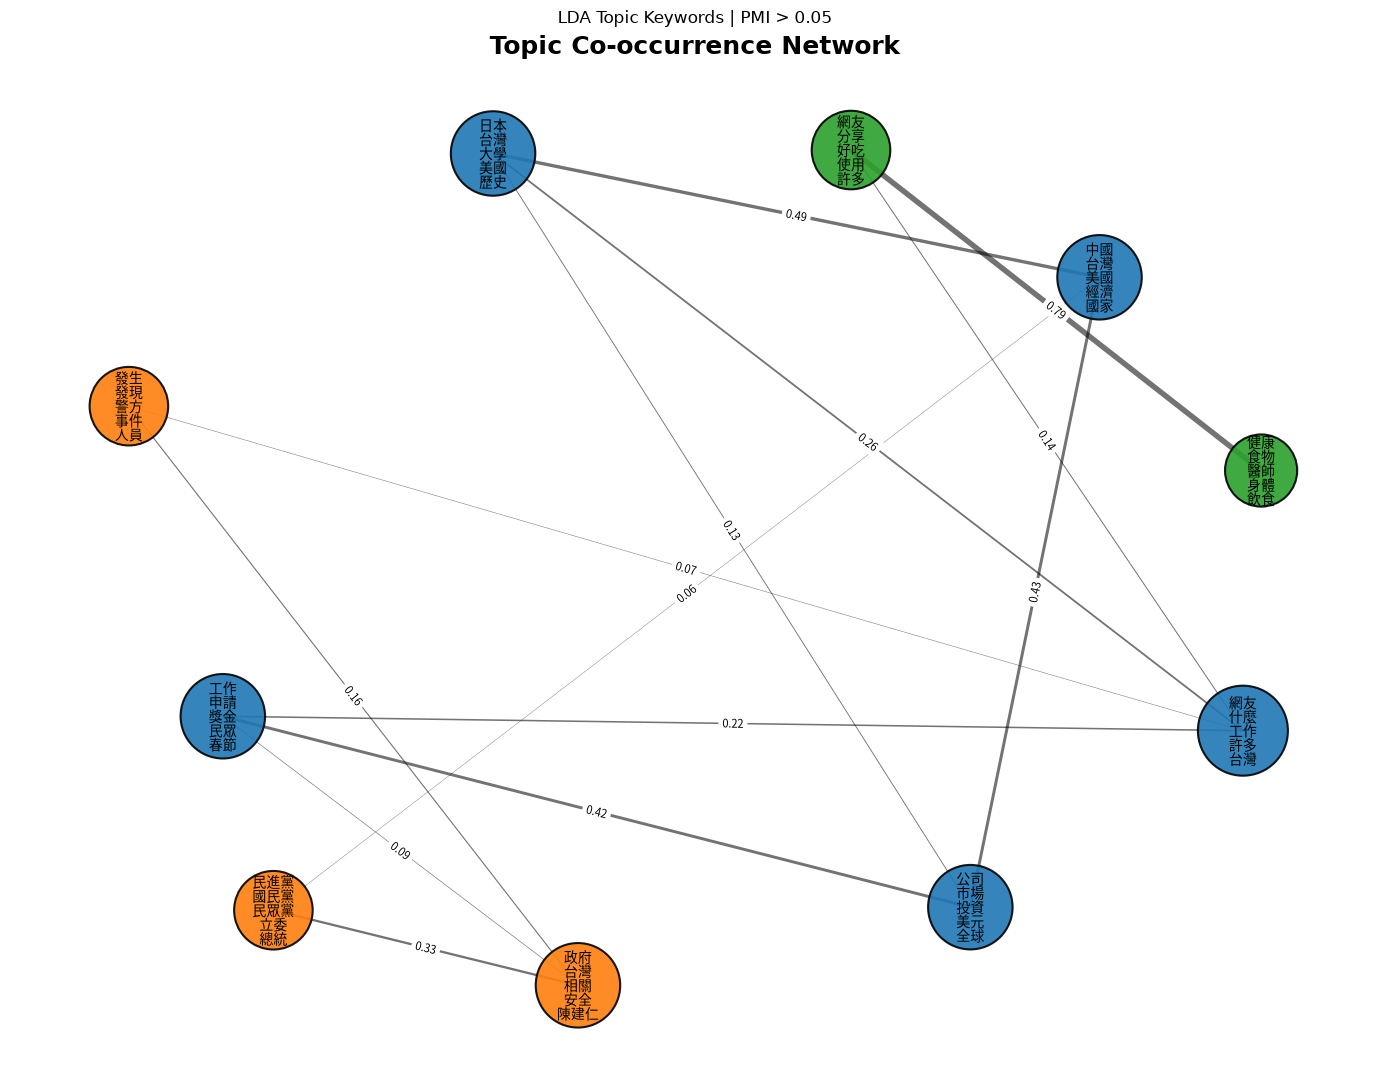

In [69]:
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# 1. Communities
# ==========================================

communities = list(
    nx.community.greedy_modularity_communities(
        G,
        weight="weight"
    )
)

community_map = {}

for i, community in enumerate(communities):
    for topic in community:
        community_map[topic] = i


# ==========================================
# 2. Degree centrality
# ==========================================

degree_centrality = nx.degree_centrality(G)


# ==========================================
# 3. Layout
# ==========================================

pos = nx.spring_layout(
    G,
    seed=42,
    weight="weight",
    k=1.8
)


# ==========================================
# 4. Figure
# ==========================================

plt.figure(figsize=(14, 11))

# 使用 matplotlib 預設 colors
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ==========================================
# 5. Node colors
# ==========================================

node_colors = [
    colors[
        community_map[node] % len(colors)
    ]
    for node in G.nodes()
]


# ==========================================
# 6. Node sizes
# ==========================================

node_sizes = [
    2200 + degree_centrality[node] * 4500
    for node in G.nodes()
]


# ==========================================
# 7. Edge widths
# ==========================================

edge_widths = [
    G[u][v]["weight"] * 5
    for u, v in G.edges()
]


# ==========================================
# 8. Draw edges
# ==========================================

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.55
)


# ==========================================
# 9. Draw nodes
# ==========================================

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.9,
    edgecolors="black",
    linewidths=1.5
)


# ==========================================
# 10. Keywords inside nodes
# ==========================================

nx.draw_networkx_labels(
    G,
    pos,
    labels=topic_labels,
    font_size=10,
    font_weight="bold",
    font_family="Noto Sans CJK JP"
)


# ==========================================
# 11. PMI labels
# ==========================================

edge_labels = {
    (u, v): f"{d['weight']:.2f}"
    for u, v, d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    font_family="Noto Sans CJK JP"
)


# ==========================================
# 12. Title
# ==========================================

plt.title(
    "Topic Co-occurrence Network",
    fontsize=18,
    fontweight="bold"
)

plt.suptitle(
    "LDA Topic Keywords | PMI > 0.05",
    fontsize=12
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [70]:
plt.savefig(
    "topic_cooccurrence_network_PMI005.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [71]:
from networkx.algorithms.community import greedy_modularity_communities

communities_filtered = list(
    greedy_modularity_communities(
        G,
        weight="weight"
    )
)

print("=== Communities ===")

for i, comm in enumerate(communities_filtered):
    print(f"Community {i}: {sorted(comm)}")

=== Communities ===
Community 0: [5, 6, 7, 9, 10]
Community 1: [3, 4, 8]
Community 2: [1, 2]


In [72]:
# 把 purity table 整理成 dict，方便對照

topic_main_tag = {
    1: "風生活",
    2: "風生活",
    3: "政治",
    4: "風生活",
    5: "國際",
    6: "風生活",
    7: "風生活",
    8: "政治",
    9: "風生活",
    10: "風生活"
}

print("=== Community vs 原始 Tag 對照 ===")

for i, comm in enumerate(communities_filtered):

    print(f"\nCommunity {i}:")

    for node in sorted(comm):

        topic_num = int(node)

        print(
            f"  Topic {topic_num} "
            f"→ 原始主 tag: {topic_main_tag[topic_num]}"
        )

=== Community vs 原始 Tag 對照 ===

Community 0:
  Topic 5 → 原始主 tag: 國際
  Topic 6 → 原始主 tag: 風生活
  Topic 7 → 原始主 tag: 風生活
  Topic 9 → 原始主 tag: 風生活
  Topic 10 → 原始主 tag: 風生活

Community 1:
  Topic 3 → 原始主 tag: 政治
  Topic 4 → 原始主 tag: 風生活
  Topic 8 → 原始主 tag: 政治

Community 2:
  Topic 1 → 原始主 tag: 風生活
  Topic 2 → 原始主 tag: 風生活


In [73]:
# ==========================================
# 儲存 BERTopic 後續分析需要的資料
# ==========================================

documents.to_csv(
    "documents_for_bertopic.csv",
    index=True
)

df_seg[["dominant_topic"]].to_csv(
    "lda_dominant_topic.csv",
    index=True
)

print("兩份檔案已同步存出")

# 確認檔案內容
print("\n=== documents_for_bertopic.csv ===")
print(documents.shape)

print("\n=== lda_dominant_topic.csv ===")
print(df_seg[["dominant_topic"]].shape)

兩份檔案已同步存出

=== documents_for_bertopic.csv ===
(5764,)

=== lda_dominant_topic.csv ===
(5764, 1)


In [74]:
lda_topic_distribution_df = pd.DataFrame(
    doc_topic_matrix,
    index=df_seg.index,
    columns=[f"topic_{i}" for i in range(1, 11)]
)

lda_topic_distribution_df.to_csv(
    "lda_topic_distribution.csv",
    index=True
)

print(
    "lda_topic_distribution.csv:",
    lda_topic_distribution_df.shape
)

lda_topic_distribution.csv: (5764, 10)


In [75]:
print("=== 目前 notebook 的主要變數 ===")

for name in dir():
    if not name.startswith("_"):
        print(name)

=== 目前 notebook 的主要變數 ===
CoherenceModel
CountVectorizer
Counter
Dictionary
G
In
LatentDirichletAllocation
Out
PMI_THRESHOLD
TfidfVectorizer
additional_stopwords
additional_stopwords_2
all_probs
avg_topics
ax
chinese_punctuation
clean_tokens
coherence_10
coherence_10_per_topic
coherence_15
coherence_5
coherence_5_per_topic
colors
combinations
comm
communities
communities_filtered
community
community_map
contains_number
cooc_count
cooc_df
cooc_matrix
count_matrix
count_vectorizer
d
degree_centrality
df_seg
dictionary
doc_topic_matrix
documents
dominant_probability
dominant_topic
edge_labels
edge_widths
exit
feature_names
fm
font_path
font_prop
gensim
get_ipython
greedy_modularity_communities
i
is_english_only
j
json
label
lda_10
lda_15
lda_5
lda_topic_distribution_df
log
n_docs
name
node
node_colors
node_sizes
np
nx
open
os
p_i
p_ij
p_j
path
pd
plt
pmi
pmi_df
pmi_edges
pos
presence
punctuation
quit
re
remove_stopwords_and_numbers
result
row
score
score_10
score_15
score_5
scores_10
scor

In [76]:
print("=== LDA community 相關變數 ===")

for name in dir():
    if "communit" in name.lower():
        print(name)

=== LDA community 相關變數 ===
communities
communities_filtered
community
community_map
greedy_modularity_communities


In [77]:
print("=== topic_keywords ===")
print(type(topic_keywords))
print(topic_keywords)

=== topic_keywords ===
<class 'dict'>
{1: ['網友', '分享', '好吃', '使用', '許多', '編輯', '推薦', '討論', '責任', '料理', '發文', '完整', '真的', '不少', '臉書'], 2: ['健康', '食物', '醫師', '身體', '飲食', '維生素', '建議', '地區', '疾病', '研究', '影響', '天氣', '幫助', '血壓', '水果'], 3: ['民進黨', '國民黨', '民眾黨', '立委', '總統', '選舉', '柯文哲', '賴清德', '國會', '立法院', '台灣', '支持', '韓國瑜', '黨團', '大選'], 4: ['發生', '發現', '警方', '事件', '人員', '調查', '影片', '男子', '金門', '進行', '目前', '學生', '法院', '導致', '要求'], 5: ['中國', '台灣', '美國', '經濟', '國家', '政府', '兩岸', '關係', '總統', '政治', '政策', '大陸', '國際', '中共', '德國'], 6: ['日本', '台灣', '大學', '美國', '歷史', '旅遊', '國家', '香港', '國際', '旅客', '世界', '川普', '泰國', '航空', '日圓'], 7: ['網友', '什麼', '工作', '許多', '台灣', '這樣', '大家', '知道', '生活', '真的', '孩子', '開始', '還是', '不少', '覺得'], 8: ['政府', '台灣', '相關', '安全', '陳建仁', '社會', '要求', '民眾', '規定', '業者', '政策', '進行', '台電', '機關', '行政院'], 9: ['工作', '申請', '獎金', '民眾', '春節', '金額', '今年', '刮刮樂', '紅包', '補助', '責任', '銀行', '財富', '年終', '期間'], 10: ['公司', '市場', '投資', '美元', '全球', '企業', '台積電', '產業', '去年', '今年', '科技', '技術', '成長', '半導體', '員工'

In [78]:
print("\n=== topic_counts ===")
print(type(topic_counts))
print(topic_counts)


=== topic_counts ===
<class 'numpy.ndarray'>
[ 848  820 1566 1257 1439  812 2213  993  831 1290]


In [79]:
print("\n=== topic_purity ===")
print(type(topic_purity))
print(topic_purity)


=== topic_purity ===
<class 'pandas.Series'>
dominant_topic
1     97.35
2     93.15
3     76.81
4     80.48
5     48.46
6     47.44
7     75.94
8     50.43
9     86.19
10    56.36
dtype: float64


In [80]:
# ============================================================
# LDA Final Topic Table
# ============================================================

lda_final_table = pd.DataFrame({
    "Topic": range(1, 11),
    "Top Keywords": [
        " | ".join(topic_keywords[i][:10])
        for i in range(1, 11)
    ],
    "Document Count": topic_counts,
    "Purity (%)": [
        topic_purity.loc[i]
        for i in range(1, 11)
    ],
    "Main Tag": [
        topic_main_tag[i]
        for i in range(1, 11)
    ]
})

print("=== LDA Final Topic Table ===")

display(lda_final_table)

=== LDA Final Topic Table ===


,Topic,Top Keywords,Document Count,Purity (%),Main Tag
0,1,網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理,848,97.35,風生活
1,2,健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究,820,93.15,風生活
2,3,民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國...,1566,76.81,政治
3,4,發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行,1257,80.48,風生活
4,5,中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治,1439,48.46,國際
5,6,日本 | 台灣 | 大學 | 美國 | 歷史 | 旅遊 | 國家 | 香港 | 國際 | 旅客,812,47.44,風生活
6,7,網友 | 什麼 | 工作 | 許多 | 台灣 | 這樣 | 大家 | 知道 | 生活 | 真的,2213,75.94,風生活
7,8,政府 | 台灣 | 相關 | 安全 | 陳建仁 | 社會 | 要求 | 民眾 | 規定 | 業者,993,50.43,政治
8,9,工作 | 申請 | 獎金 | 民眾 | 春節 | 金額 | 今年 | 刮刮樂 | 紅包 | 補助,831,86.19,風生活
9,10,公司 | 市場 | 投資 | 美元 | 全球 | 企業 | 台積電 | 產業 | 去年 | 今年,1290,56.36,風生活


In [81]:
dominant_topic_counts = pd.Series(
    dominant_topic
).value_counts().sort_index()

print("=== Dominant Topic Counts ===")
print(dominant_topic_counts)

print("\nTotal documents:", dominant_topic_counts.sum())
print("Expected documents:", len(dominant_topic))

=== Dominant Topic Counts ===
0     453
1     467
2    1078
3     666
4     681
5     156
6     960
7     349
8     333
9     621
Name: count, dtype: int64

Total documents: 5764
Expected documents: 5764


In [82]:
#正式的table
# ============================================================
# LDA Final Topic Table - Correct Document Count
# ============================================================

lda_final_table = pd.DataFrame({
    "Topic": range(1, 11),

    "Top Keywords": [
        " | ".join(topic_keywords[i][:10])
        for i in range(1, 11)
    ],

    "Document Count": [
        dominant_topic_counts.get(i - 1, 0)
        for i in range(1, 11)
    ],

    "Document (%)": [
        dominant_topic_counts.get(i - 1, 0)
        / len(dominant_topic) * 100
        for i in range(1, 11)
    ],

    "Purity (%)": [
        topic_purity.loc[i]
        for i in range(1, 11)
    ],

    "Main Tag": [
        topic_main_tag[i]
        for i in range(1, 11)
    ]
})

print("=== LDA Final Topic Table ===")

display(
    lda_final_table.round({
        "Document (%)": 2,
        "Purity (%)": 2
    })
)

=== LDA Final Topic Table ===


,Topic,Top Keywords,Document Count,Document (%),Purity (%),Main Tag
0,1,網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理,453,7.86,97.35,風生活
1,2,健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究,467,8.10,93.15,風生活
2,3,民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國...,1078,18.70,76.81,政治
3,4,發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行,666,11.55,80.48,風生活
4,5,中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治,681,11.81,48.46,國際
5,6,日本 | 台灣 | 大學 | 美國 | 歷史 | 旅遊 | 國家 | 香港 | 國際 | 旅客,156,2.71,47.44,風生活
6,7,網友 | 什麼 | 工作 | 許多 | 台灣 | 這樣 | 大家 | 知道 | 生活 | 真的,960,16.66,75.94,風生活
7,8,政府 | 台灣 | 相關 | 安全 | 陳建仁 | 社會 | 要求 | 民眾 | 規定 | 業者,349,6.05,50.43,政治
8,9,工作 | 申請 | 獎金 | 民眾 | 春節 | 金額 | 今年 | 刮刮樂 | 紅包 | 補助,333,5.78,86.19,風生活
9,10,公司 | 市場 | 投資 | 美元 | 全球 | 企業 | 台積電 | 產業 | 去年 | 今年,621,10.77,56.36,風生活


In [83]:
print("=== LDA community_map ===")
print(type(community_map))
print(community_map)

=== LDA community_map ===
<class 'dict'>
{5: 0, 6: 0, 7: 0, 9: 0, 10: 0, 8: 1, 3: 1, 4: 1, 1: 2, 2: 2}


In [84]:
#add community
# ============================================================
# LDA Final Topic Table - Complete Version
# ============================================================

lda_final_table = pd.DataFrame({
    "Topic": range(1, 11),

    "Top Keywords": [
        " | ".join(topic_keywords[i][:10])
        for i in range(1, 11)
    ],

    "Document Count": [
        dominant_topic_counts.get(i - 1, 0)
        for i in range(1, 11)
    ],

    "Document (%)": [
        dominant_topic_counts.get(i - 1, 0)
        / len(dominant_topic) * 100
        for i in range(1, 11)
    ],

    "Purity (%)": [
        topic_purity.loc[i]
        for i in range(1, 11)
    ],

    "Main Tag": [
        topic_main_tag[i]
        for i in range(1, 11)
    ],

    "Community": [
        community_map[i]
        for i in range(1, 11)
    ]
})


# ============================================================
# 顯示
# ============================================================

print("=== FINAL LDA TOPIC TABLE ===")

display(
    lda_final_table.round({
        "Document (%)": 2,
        "Purity (%)": 2
    })
)

=== FINAL LDA TOPIC TABLE ===


,Topic,Top Keywords,Document Count,Document (%),Purity (%),Main Tag,Community
0,1,網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理,453,7.86,97.35,風生活,2
1,2,健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究,467,8.10,93.15,風生活,2
2,3,民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國...,1078,18.70,76.81,政治,1
3,4,發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行,666,11.55,80.48,風生活,1
4,5,中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治,681,11.81,48.46,國際,0
5,6,日本 | 台灣 | 大學 | 美國 | 歷史 | 旅遊 | 國家 | 香港 | 國際 | 旅客,156,2.71,47.44,風生活,0
6,7,網友 | 什麼 | 工作 | 許多 | 台灣 | 這樣 | 大家 | 知道 | 生活 | 真的,960,16.66,75.94,風生活,0
7,8,政府 | 台灣 | 相關 | 安全 | 陳建仁 | 社會 | 要求 | 民眾 | 規定 | 業者,349,6.05,50.43,政治,1
8,9,工作 | 申請 | 獎金 | 民眾 | 春節 | 金額 | 今年 | 刮刮樂 | 紅包 | 補助,333,5.78,86.19,風生活,0
9,10,公司 | 市場 | 投資 | 美元 | 全球 | 企業 | 台積電 | 產業 | 去年 | 今年,621,10.77,56.36,風生活,0


In [85]:
lda_final_table.to_csv(
    "LDA_final_topic_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print("LDA final topic table 已儲存")

LDA final topic table 已儲存


In [86]:
import pandas as pd
from collections import defaultdict

# ============================================================
# Step 4A: LDA Community Interpretation
# ============================================================

# 目前已有：
# topic_keywords
# community_map
# topic_main_tag

# community_map:
# {5: 0, 6: 0, 7: 0, 9: 0, 10: 0,
#  8: 1, 3: 1, 4: 1,
#  1: 2, 2: 2}

lda_community_topics = defaultdict(list)

for topic_id, community_id in community_map.items():
    lda_community_topics[community_id].append(topic_id)

print("=== LDA Community Interpretation ===")

lda_community_rows = []

for community_id in sorted(lda_community_topics):

    topics_in_comm = sorted(lda_community_topics[community_id])

    # 收集所有 topic keywords
    all_keywords = []

    for topic_id in topics_in_comm:
        keywords = topic_keywords[topic_id]
        all_keywords.extend(keywords[:10])

    # 去重但保留順序
    unique_keywords = list(dict.fromkeys(all_keywords))

    # 收集 main tags
    tags = [
        topic_main_tag[t]
        for t in topics_in_comm
        if t in topic_main_tag
    ]

    tag_counts = pd.Series(tags).value_counts()

    main_tag = tag_counts.index[0] if len(tag_counts) > 0 else "N/A"

    lda_community_rows.append({
        "Community": f"LDA-C{community_id}",
        "Topics": ", ".join([f"T{t}" for t in topics_in_comm]),
        "Keywords": " | ".join(unique_keywords[:20]),
        "Main Tag": main_tag
    })

lda_community_df = pd.DataFrame(lda_community_rows)

print(lda_community_df.to_string(index=False))

=== LDA Community Interpretation ===
Community              Topics                                                                                                Keywords Main Tag
   LDA-C0 T5, T6, T7, T9, T10       中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治 | 日本 | 大學 | 歷史 | 旅遊 | 香港 | 國際 | 旅客 | 網友 | 什麼 | 工作      風生活
   LDA-C1          T3, T4, T8 民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國會 | 立法院 | 發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行       政治
   LDA-C2              T1, T2      網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理 | 健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究      風生活


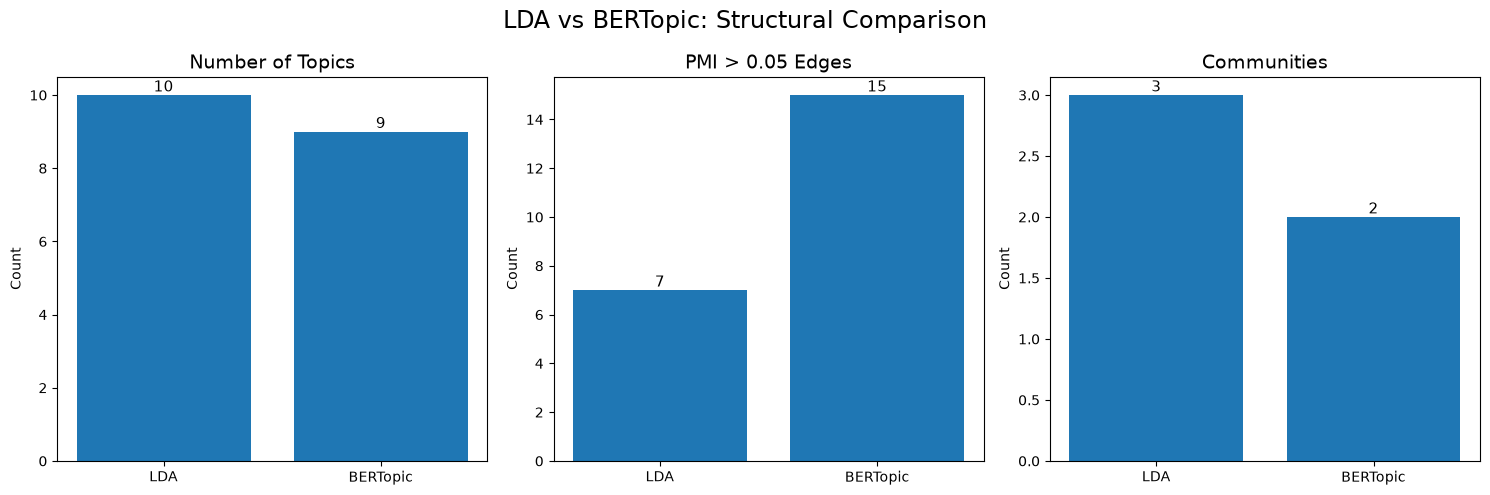

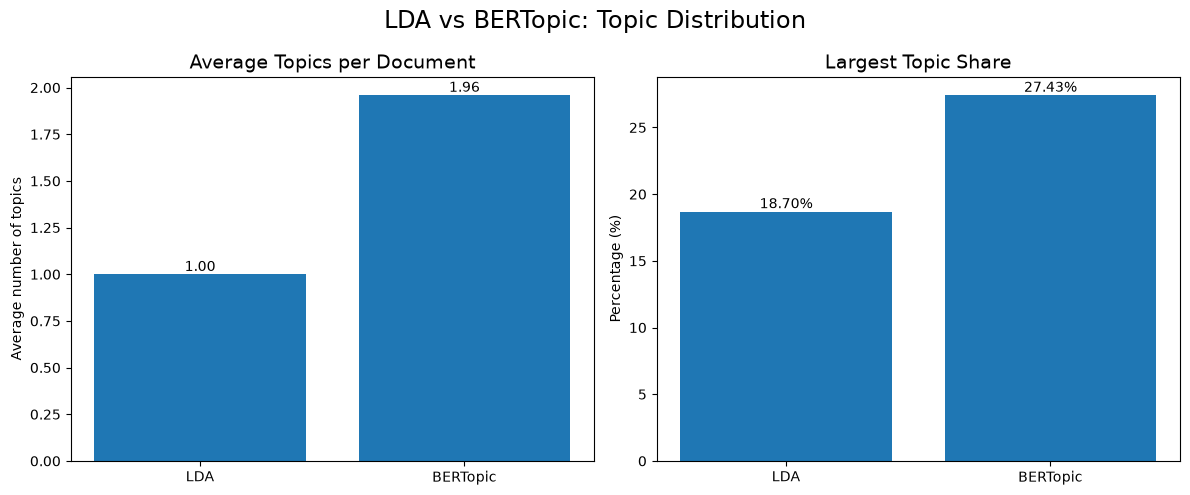

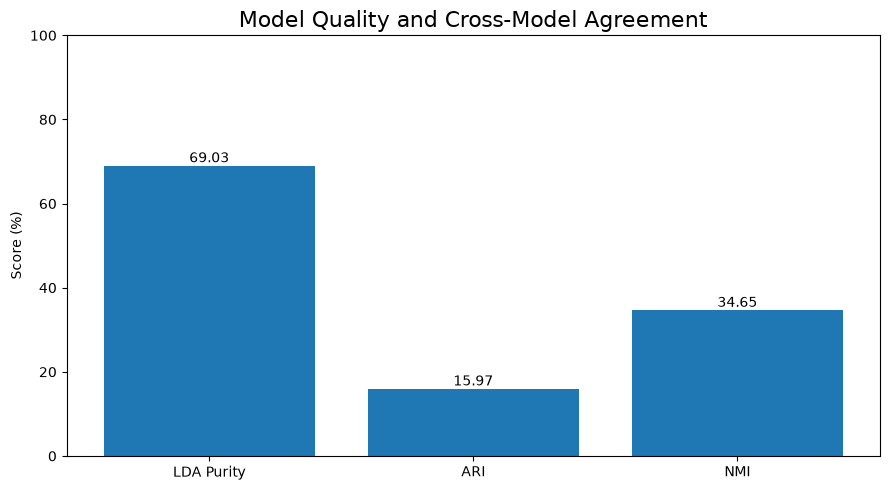

=== FINAL MODEL SUMMARY ===


,Metric,LDA,BERTopic
0,Number of topics,10.00,9
1,Documents,5764.00,5764
2,Average topics per document,1.00,1.96
3,PMI > 0.05 edges,7.00,15
4,Number of communities,3.00,2
5,Largest topic share (%),18.70,27.43
6,Average topic purity (%),69.03,N/A


In [1]:
# ============================================================
# Step 7：Final Visual Summary
# LDA vs BERTopic
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Final results
# ------------------------------------------------------------

results = {
    "LDA": {
        "topics": 10,
        "documents": 5764,
        "avg_topics_per_doc": 1.00,
        "pmi_edges": 7,
        "communities": 3,
        "largest_topic_share": 18.70,
        "avg_purity": 69.03
    },

    "BERTopic": {
        "topics": 9,
        "documents": 5764,
        "avg_topics_per_doc": 1.96,
        "pmi_edges": 15,
        "communities": 2,
        "largest_topic_share": 27.43,
        "avg_purity": np.nan
    }
}

# ------------------------------------------------------------
# 2. Figure 1 — Structural Comparison
# ------------------------------------------------------------

models = ["LDA", "BERTopic"]

metrics = [
    ("Number of Topics", "topics"),
    ("PMI > 0.05 Edges", "pmi_edges"),
    ("Communities", "communities")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, key) in zip(axes, metrics):

    values = [results[m][key] for m in models]

    bars = ax.bar(models, values)

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Count")

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{value}",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.suptitle(
    "LDA vs BERTopic: Structural Comparison",
    fontsize=17
)

plt.tight_layout()

plt.savefig(
    "Step7_structural_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Figure 2 — Topic Distribution
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average topics per document
values = [
    results["LDA"]["avg_topics_per_doc"],
    results["BERTopic"]["avg_topics_per_doc"]
]

bars = axes[0].bar(models, values)

axes[0].set_title(
    "Average Topics per Document",
    fontsize=14
)

axes[0].set_ylabel("Average number of topics")

for bar, value in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# Largest topic share
values = [
    results["LDA"]["largest_topic_share"],
    results["BERTopic"]["largest_topic_share"]
]

bars = axes[1].bar(models, values)

axes[1].set_title(
    "Largest Topic Share",
    fontsize=14
)

axes[1].set_ylabel("Percentage (%)")

for bar, value in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.suptitle(
    "LDA vs BERTopic: Topic Distribution",
    fontsize=17
)

plt.tight_layout()

plt.savefig(
    "Step7_topic_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 4. Figure 3 — Model Quality / Agreement
# ------------------------------------------------------------

quality_metrics = [
    "LDA Purity",
    "ARI",
    "NMI"
]

quality_values = [
    69.03,
    15.97,   # ARI 0.1597 → percentage for visualization
    34.65    # NMI 0.3465 → percentage for visualization
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    quality_metrics,
    quality_values
)

ax.set_ylabel("Score (%)")

ax.set_ylim(0, 100)

ax.set_title(
    "Model Quality and Cross-Model Agreement",
    fontsize=16
)

for bar, value in zip(bars, quality_values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "Step7_model_quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. Final summary table
# ------------------------------------------------------------

final_summary = pd.DataFrame({
    "Metric": [
        "Number of topics",
        "Documents",
        "Average topics per document",
        "PMI > 0.05 edges",
        "Number of communities",
        "Largest topic share (%)",
        "Average topic purity (%)"
    ],

    "LDA": [
        results["LDA"]["topics"],
        results["LDA"]["documents"],
        results["LDA"]["avg_topics_per_doc"],
        results["LDA"]["pmi_edges"],
        results["LDA"]["communities"],
        results["LDA"]["largest_topic_share"],
        results["LDA"]["avg_purity"]
    ],

    "BERTopic": [
        results["BERTopic"]["topics"],
        results["BERTopic"]["documents"],
        results["BERTopic"]["avg_topics_per_doc"],
        results["BERTopic"]["pmi_edges"],
        results["BERTopic"]["communities"],
        results["BERTopic"]["largest_topic_share"],
        "N/A"
    ]
})

print("=== FINAL MODEL SUMMARY ===")

display(final_summary)